# Week 7 - Model Optimisation and Trade-offs (interim)
Vishwesh Pattanaik | CariSurg MedTech Pathways 2026

Question: does a more complex model (XGBoost) earn its complexity over the Week 6 baseline?
Same data, same 80/20 split, **seed 42**. Target = `esi` (1 = most urgent).

### 1. Setup (reuse the Week 6 split)

In [2]:
import pandas as pd, numpy as np, time
from google.colab import drive
drive.mount('/content/drive')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")
cc  = [c for c in df.columns if c.startswith("cc_")]
y   = df["esi"].astype(int)
num = ["age","triage_vital_hr","triage_vital_sbp","triage_vital_dbp","triage_vital_rr",
       "triage_vital_o2","triage_vital_temp","triage_glucose","triage_vital_o2_device"]
X = pd.concat([df[num], df[cc], pd.get_dummies(df[["gender","arrivalmode"]], drop_first=True)], axis=1)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
sc = StandardScaler().fit(Xtr[num]); Xtr, Xte = Xtr.copy(), Xte.copy()
Xtr[num] = sc.transform(Xtr[num]); Xte[num] = sc.transform(Xte[num])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Baselines (from Week 6)

In [3]:
lr = LogisticRegression(max_iter=2000, random_state=42).fit(Xtr, ytr)
dt = DecisionTreeClassifier(max_depth=6, random_state=42).fit(Xtr, ytr)

### 3. Complex model - XGBoost
Gradient boosting was the model named in the Phase 1 proposal. 300 trees, depth 6, learning rate 0.1, with column and row subsampling to limit overfitting. XGBoost needs 0-indexed labels, so ESI 1-5 becomes 0-4 for training and is shifted back for reporting.

In [4]:
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8, random_state=42,
                    eval_metric="mlogloss", n_jobs=4)
xgb.fit(Xtr, ytr-1)
pxgb = xgb.predict(Xte) + 1
print(classification_report(yte, pxgb, digits=3))

              precision    recall  f1-score   support

           1      1.000     0.062     0.118        16
           2      0.754     0.635     0.690      3585
           3      0.679     0.796     0.733      5402
           4      0.647     0.575     0.609      1779
           5      0.379     0.136     0.200       243

    accuracy                          0.693     11025
   macro avg      0.692     0.441     0.470     11025
weighted avg      0.692     0.693     0.686     11025



### 4. Six-axis benchmark

In [5]:
def benchmark(model, name, xgb=False):
    yt = ytr-1 if xgb else ytr
    t0=time.time(); model.fit(Xtr, yt); train_t=time.time()-t0
    t0=time.time(); p=model.predict(Xte); infer_ms=(time.time()-t0)/len(Xte)*1000
    if xgb: p=p+1
    return {"Model":name,
            "Accuracy":round(accuracy_score(yte,p),3),
            "Macro precision":round(precision_score(yte,p,average='macro'),3),
            "Macro recall":round(recall_score(yte,p,average='macro'),3),
            "Macro F1":round(f1_score(yte,p,average='macro'),3),
            "ESI-1 recall":round(recall_score(yte,p,labels=[1],average=None)[0],3),
            "Train time (s)":round(train_t,1),
            "Inference (ms/pred)":round(infer_ms,3)}

table = pd.DataFrame([
    benchmark(LogisticRegression(max_iter=2000,random_state=42),"Logistic regression"),
    benchmark(DecisionTreeClassifier(max_depth=6,random_state=42),"Decision tree (d=6)"),
    benchmark(XGBClassifier(n_estimators=300,max_depth=6,learning_rate=0.1,subsample=0.8,
                            colsample_bytree=0.8,random_state=42,eval_metric="mlogloss",n_jobs=4),
              "XGBoost", xgb=True),
])
table

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Macro precision,Macro recall,Macro F1,ESI-1 recall,Train time (s),Inference (ms/pred)
0,Logistic regression,0.685,0.666,0.476,0.518,0.250,31.7,0.004
1,Decision tree (d=6),0.560,0.252,0.251,0.226,0.000,0.4,0.001
2,XGBoost,0.693,0.692,0.441,0.470,0.062,28.7,0.032


### 5. Seventh axis - interpretability
- **Logistic regression:** one coefficient per feature. You can tell Dr Reyes "low oxygen and chest pain pushed this patient up" in a sentence. Fully explainable.
- **Decision tree (depth 6):** a path of yes/no splits you can read off. Explainable, but the model is weak.
- **XGBoost:** 300 trees. No single explanation without a tool like SHAP. Feature importances give a global picture only, not a per-patient reason a clinician can check at the bedside.

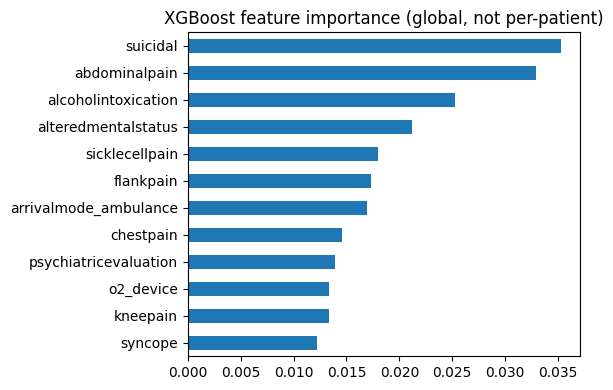

In [6]:
imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
imp.index = [i.replace("cc_","").replace("triage_vital_","") for i in imp.index]
imp[::-1].plot.barh(figsize=(6,4), title="XGBoost feature importance (global, not per-patient)")
plt.tight_layout(); plt.show()

### 6. Early read
XGBoost adds less than one point of accuracy over logistic regression (0.693 vs 0.685) and is **worse** on the two numbers that matter for triage safety: macro F1 (0.47 vs 0.52) and ESI-1 recall (0.06 vs 0.25). It also costs about 2.5 times the training time, roughly 13 times the inference time per prediction, and gives up the per-patient explanation a clinician can check.

On this dataset the complexity does not pay for itself. The full cost-benefit memo (final) will argue for keeping logistic regression for Phase 3.